ALLUVO_Workflow
 ===================================

PHASE 0 — Generate synthetic data  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;              ✔ Done 

PHASE 1 — Virtual Environment   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;                 ✔ Done  

PHASE 2 — Data Pipeline             &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;             ✔ Done  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Load Data  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Data Cleaning  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Feature Engineering  

PHASE 3 — Interaction Matrix         &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;            ✔ Done  

PHASE 4 — Models           &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ✔ Done<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Content-Based Model        
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Collaborative Filtering    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Popularity Model            
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;• Time Decay Model            

PHASE 5 — Hybrid Model     &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  ✔ Done <br>

PHASE 6 — Evaluation  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  ✔ Done <br>

PHASE 7 — Save Models  

PHASE 8 — Inference Pipeline  

PHASE 9 — FastAPI (Production)

In [2]:
import os
os.chdir(r"H:\study\AI\vs code\ALLUVO-RecommendationSystem")
print(os.getcwd())

H:\study\AI\vs code\ALLUVO-RecommendationSystem


Users Dataset

In [3]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)

num_users = 2000

# Age distribution (18-60 )
def generate_age():
    r = random.random()
    if r < 0.35:
        return random.randint(18,24)
    elif r < 0.75:
        return random.randint(25,34)
    elif r < 0.95:
        return random.randint(35,45)
    else:
        return random.randint(46,60)

# Interests ( 7 interest)
categories = ["Fashion","Beauty","Fitness","Technology","Home","Sports","Gaming"]

def generate_interests():
    return random.sample(categories, random.randint(2,4))

# Followed brands ( 30 brand)
def generate_followed_brands():
    return random.sample(range(1,31), random.randint(1,5))

users = []

for i in range(1, num_users+1):
    user = {
        "user_id": i,
        "age": generate_age(),
        "gender": random.choice(["Male","Female"]),
        "interests": generate_interests(),
        "followed_brands": generate_followed_brands(),
        "created_at": datetime.now() - timedelta(days=random.randint(0,365)) # Account creation date within the last year
    }
    users.append(user)

users_df = pd.DataFrame(users)

print(users_df.head())

   user_id  age  gender                            interests  \
0        1   27  Female  [Home, Fashion, Technology, Beauty]   
1        2   35    Male     [Fitness, Home, Fashion, Beauty]   
2        3   34  Female              [Gaming, Fitness, Home]   
3        4   26    Male                      [Fitness, Home]   
4        5   34    Male                       [Sports, Home]   

      followed_brands                 created_at  
0  [22, 17, 5, 8, 23] 2025-08-07 21:33:24.514551  
1                 [5] 2025-12-16 21:33:24.514576  
2                [22] 2026-01-18 21:33:24.514590  
3            [16, 11] 2025-06-21 21:33:24.514601  
4             [26, 4] 2026-02-13 21:33:24.514611  


brands Dataset

In [4]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

num_brands = 30

categories = ["Fashion","Beauty","Fitness","Technology","Home","Sports","Gaming"]

brands = []

for i in range(1, num_brands+1):
    brand = {
        "brand_id": i,
        "brand_name": f"Brand {i}",
        "category": random.choice(categories),
        "brand_popularity_score": round(random.uniform(20,100),2)  # realistic number
    }
    brands.append(brand)

brands_df = pd.DataFrame(brands)
print(brands_df.head())

   brand_id brand_name    category  brand_popularity_score
0         1    Brand 1        Home                   48.38
1         2    Brand 2     Fashion                   87.16
2         3    Brand 3      Sports                   96.98
3         4    Brand 4  Technology                   97.21
4         5    Brand 5     Fashion                   42.50


reels Dataset

In [5]:
num_reels = 3000

reels = []

for i in range(1, num_reels+1):
    brand_id = random.randint(1,30)  # choose a random brand from the 30
    category = None  # will fetch it from Brands_df
    # fetch category from Brands_df
    category = brands_df.loc[brands_df['brand_id'] == brand_id, 'category'].values[0]
    
    reel = {
        "reel_id": i,
        "brand_id": brand_id,
        "category": category,
        "price": round(random.uniform(10,500),2),
        "created_at": datetime.now() - timedelta(days=random.randint(0,90)),
        "video_duration": random.randint(10,60)  # seconds
    }
    reels.append(reel)

reels_df = pd.DataFrame(reels)
print(reels_df.head())

   reel_id  brand_id    category   price                 created_at  \
0        1        19  Technology   50.68 2026-04-21 21:33:24.608517   
1        2         3      Sports  171.81 2026-02-19 21:33:24.610392   
2        3         8     Fitness  254.79 2026-04-19 21:33:24.611216   
3        4        18     Fashion  388.44 2026-03-12 21:33:24.611720   
4        5         1        Home   86.80 2026-02-09 21:33:24.612096   

   video_duration  
0              22  
1              27  
2              30  
3              50  
4              21  


interactions Dataset

In [6]:
interactions = []

for idx, user in users_df.iterrows():
    # each user potentially interacts with 50–150 reels
    num_reels_to_interact = random.randint(50,150)
    reel_sample = reels_df.sample(n=num_reels_to_interact)
    
    for _, reel in reel_sample.iterrows():
        # calculate P(interaction)
        p = 0.1
        if reel['category'] in user['interests']:
            p = 0.6
        elif reel['brand_id'] in user['followed_brands']:
            p = 0.3
        
        interacted = np.random.rand() < p
        if not interacted:
            continue  # skip if the user did not interact
        
        # types of interaction
        like = int(np.random.rand() < 0.3)
        comment = int(np.random.rand() < 0.1)
        purchase = int(np.random.rand() < 0.03)
        watch_ratio = round(random.uniform(0.1,1.0),2)
        if reel['category'] in user['interests'] or reel['brand_id'] in user['followed_brands']:
            watch_ratio = round(random.uniform(0.5,1.0),2)
        
        interaction = {
            "user_id": user['user_id'],
            "reel_id": reel['reel_id'],
            "view": 1,
            "watch_ratio": watch_ratio,
            "like": like,
            "comment": comment,
            "purchase": purchase,
            "timestamp": reel['created_at'] + timedelta(days=random.randint(0,10))
        }
        interactions.append(interaction)

interactions_df = pd.DataFrame(interactions)
print(interactions_df.head())
print("Total interactions:", len(interactions_df))

   user_id  reel_id  view  watch_ratio  like  comment  purchase  \
0        1     1802     1         0.76     1        0         0   
1        1      252     1         0.78     1        0         1   
2        1     1118     1         0.53     0        0         0   
3        1     2777     1         0.64     1        0         0   
4        1      901     1         0.63     1        0         0   

                   timestamp  
0 2026-02-17 21:33:25.298220  
1 2026-02-23 21:33:24.725554  
2 2026-03-21 21:33:25.060429  
3 2026-04-16 21:33:25.623261  
4 2026-02-09 21:33:24.977830  
Total interactions: 64636


load_data

In [7]:
import pandas as pd
import ast

# load files
users_df = pd.read_csv("data/raw/users.csv")
brands_df = pd.read_csv("data/raw/brands.csv")
reels_df = pd.read_csv("data/raw/reels.csv")
interactions_df = pd.read_csv("data/raw/interactions.csv")

# convert columns that contain lists
users_df['interests'] = users_df['interests'].apply(ast.literal_eval)
users_df['followed_brands'] = users_df['followed_brands'].apply(ast.literal_eval)

# convert dates
users_df['created_at'] = pd.to_datetime(users_df['created_at'])
reels_df['created_at'] = pd.to_datetime(reels_df['created_at'])
interactions_df['timestamp'] = pd.to_datetime(interactions_df['timestamp'])

# quick test
print(users_df.head())
print(brands_df.head())
print(reels_df.head())
print(interactions_df.head())

   user_id  age  gender                            interests  \
0        1   22  Female  [Technology, Gaming, Fashion, Home]   
1        2   33  Female                     [Sports, Beauty]   
2        3   42  Female                 [Sports, Technology]   
3        4   37    Male                    [Beauty, Fashion]   
4        5   31    Male     [Home, Fitness, Sports, Fashion]   

      followed_brands                 created_at  
0             [22, 9] 2025-08-03 15:45:20.197817  
1        [22, 28, 24] 2025-05-22 15:45:20.197847  
2         [3, 23, 15] 2026-02-10 15:45:20.197862  
3  [13, 27, 4, 10, 3] 2025-10-30 15:45:20.197875  
4             [14, 1] 2025-08-28 15:45:20.197889  
   brand_id brand_name    category  brand_popularity_score
0         1    Brand 1  Technology                   95.98
1         2    Brand 2      Gaming                   52.39
2         3    Brand 3     Fitness                   78.73
3         4    Brand 4      Sports                   39.70
4         5   

Feature Engineering

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer

# convert user interests to one-hot encoding
mlb = MultiLabelBinarizer()
user_interests = pd.DataFrame(
    mlb.fit_transform(users_df['interests']),
    columns=[f"interest_{c}" for c in mlb.classes_],
    index=users_df.index
)
users_df = pd.concat([users_df, user_interests], axis=1)

# add column for total interactions per user
user_interactions_count = interactions_df.groupby('user_id').size().rename('total_interactions')
users_df = users_df.merge(user_interactions_count, on='user_id', how='left').fillna(0)

# add column for total views per reel
reel_views_count = interactions_df.groupby('reel_id')['view'].sum().rename('total_views')
reels_df = reels_df.merge(reel_views_count, on='reel_id', how='left').fillna(0)

In [9]:
print(users_df.head())


   user_id  age  gender                            interests  \
0        1   22  Female  [Technology, Gaming, Fashion, Home]   
1        2   33  Female                     [Sports, Beauty]   
2        3   42  Female                 [Sports, Technology]   
3        4   37    Male                    [Beauty, Fashion]   
4        5   31    Male     [Home, Fitness, Sports, Fashion]   

      followed_brands                 created_at  interest_Beauty  \
0             [22, 9] 2025-08-03 15:45:20.197817                0   
1        [22, 28, 24] 2025-05-22 15:45:20.197847                1   
2         [3, 23, 15] 2026-02-10 15:45:20.197862                0   
3  [13, 27, 4, 10, 3] 2025-10-30 15:45:20.197875                1   
4             [14, 1] 2025-08-28 15:45:20.197889                0   

   interest_Fashion  interest_Fitness  interest_Gaming  interest_Home  \
0                 1                 0                1              1   
1                 0                 0                0

In [10]:
print(reels_df.head())

   reel_id  brand_id category   price                 created_at  \
0        1        11   Gaming  301.29 2025-12-05 15:49:20.634276   
1        2        23   Gaming   83.47 2026-02-11 15:49:20.634908   
2        3         4   Sports  471.74 2025-12-29 15:49:20.635441   
3        4        24   Beauty  290.25 2026-01-09 15:49:20.635924   
4        5        11   Gaming   54.94 2026-01-22 15:49:20.636273   

   video_duration  total_views  
0              13           28  
1              33           26  
2              36           25  
3              38           15  
4              49           32  


Interaction Matrix

In [11]:
interaction_matrix = interactions_df.pivot_table(
    index='user_id',
    columns='reel_id',
    values='watch_ratio',
    fill_value=0
)

print(interaction_matrix.head())

# save a temporary copy for testing
interaction_matrix.to_csv("data/processed/user_item_matrix.csv")

reel_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                              ...   
1         0.0  0.00  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
2         0.0  0.51  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
3         0.0  0.00  0.61   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
4         0.0  0.00  0.00   0.0   0.0   0.0  0.00   0.0   0.0   0.0  ...   
5         0.0  0.00  0.00   0.0   0.0   0.0  0.93   0.0   0.0   0.0  ...   

reel_id  2991  2992  2993  2994  2995  2996  2997  2998  2999  3000  
user_id                                                              
1         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
5         0.0   0.0   0.0   0.0   0.0   0.0   0

Collaborative Filtering (Matrix Factorization)

In [12]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

# number of latent factors
n_factors = 50

svd = TruncatedSVD(n_components=n_factors, random_state=42)

# transform the matrix
user_latent = svd.fit_transform(interaction_matrix)
item_latent = svd.components_

print("User latent shape:", user_latent.shape)
print("Item latent shape:", item_latent.shape)

User latent shape: (2000, 50)
Item latent shape: (50, 3000)


In [13]:
predicted_matrix = np.dot(user_latent, item_latent)

predicted_df = pd.DataFrame(
    predicted_matrix,
    index=interaction_matrix.index,
    columns=interaction_matrix.columns
)

print(predicted_df.head())

reel_id      1         2         3         4         5         6         7     \
user_id                                                                         
1        0.015864 -0.011917 -0.016780 -0.004151  0.010707  0.004596  0.008659   
2        0.003676  0.017270 -0.001086  0.011078  0.000928 -0.002292  0.005202   
3        0.008200  0.011903  0.043822  0.002892  0.008682  0.046328  0.019253   
4        0.028275 -0.019751  0.000805  0.013518 -0.001955 -0.009487  0.009216   
5        0.009588 -0.012047  0.010642  0.033204  0.009614  0.025486  0.043027   

reel_id      8         9         10    ...      2991      2992      2993  \
user_id                                ...                                 
1        0.011783  0.000719  0.004216  ... -0.004669 -0.012990  0.012726   
2        0.013016  0.001589  0.007165  ...  0.007382 -0.004795  0.009254   
3       -0.000595 -0.007517  0.027612  ...  0.019211 -0.000962  0.013429   
4        0.021495 -0.010344  0.007343  ... -0.021101

In [14]:
already_watched = interaction_matrix > 0
predicted_df[already_watched] = 0

In [15]:
def recommend_cf(user_id, top_k=10):
    user_scores = predicted_df.loc[user_id]
    top_reels = user_scores.sort_values(ascending=False).head(top_k)
    return top_reels

recommend_cf(111)

reel_id
829     0.208848
2186    0.203804
1876    0.197189
2621    0.196950
2388    0.188297
619     0.174191
2698    0.172656
1263    0.171992
1840    0.167003
2019    0.165252
Name: 111, dtype: float64

In [16]:
user = users_df[users_df['user_id'] == 111]
print("User interests:", user['interests'].values)

User interests: [list(['Sports', 'Beauty', 'Home', 'Gaming'])]


In [17]:
top_reels = recommend_cf(111)
top_reel_categories = reels_df[reels_df['reel_id'].isin(top_reels.index)]['category']
print(top_reel_categories)

618      Beauty
828      Beauty
1262     Beauty
1839       Home
1875     Gaming
2018       Home
2185     Beauty
2387     Beauty
2620       Home
2697    Fitness
Name: category, dtype: str


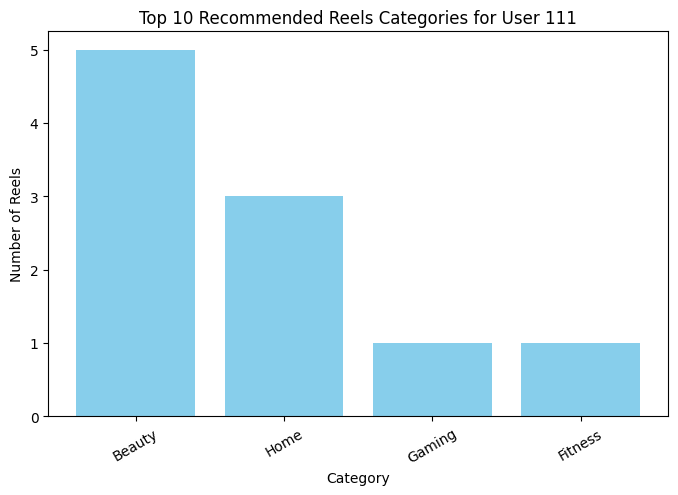

In [18]:
import matplotlib.pyplot as plt

# user interests
user_id = 111
user_interests = users_df[users_df['user_id'] == user_id]['interests'].values[0]

# recommended reels
top_reels = recommend_cf(user_id)
top_reel_categories = reels_df[reels_df['reel_id'].isin(top_reels.index)]['category']

# count reels per category
category_counts = top_reel_categories.value_counts()

# plot Bar Chart
plt.figure(figsize=(8,5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue')
plt.title(f"Top {len(top_reels)} Recommended Reels Categories for User {user_id}")
plt.ylabel("Number of Reels")
plt.xlabel("Category")

# highlight user interests
for bar in bars:
    if bar.get_x() + bar.get_width()/2 in [top_reel_categories.index[top_reel_categories == c][0] for c in user_interests if c in category_counts.index]:
        bar.set_color('orange')

# add line or text to indicate user interests
plt.xticks(rotation=30)
plt.show()

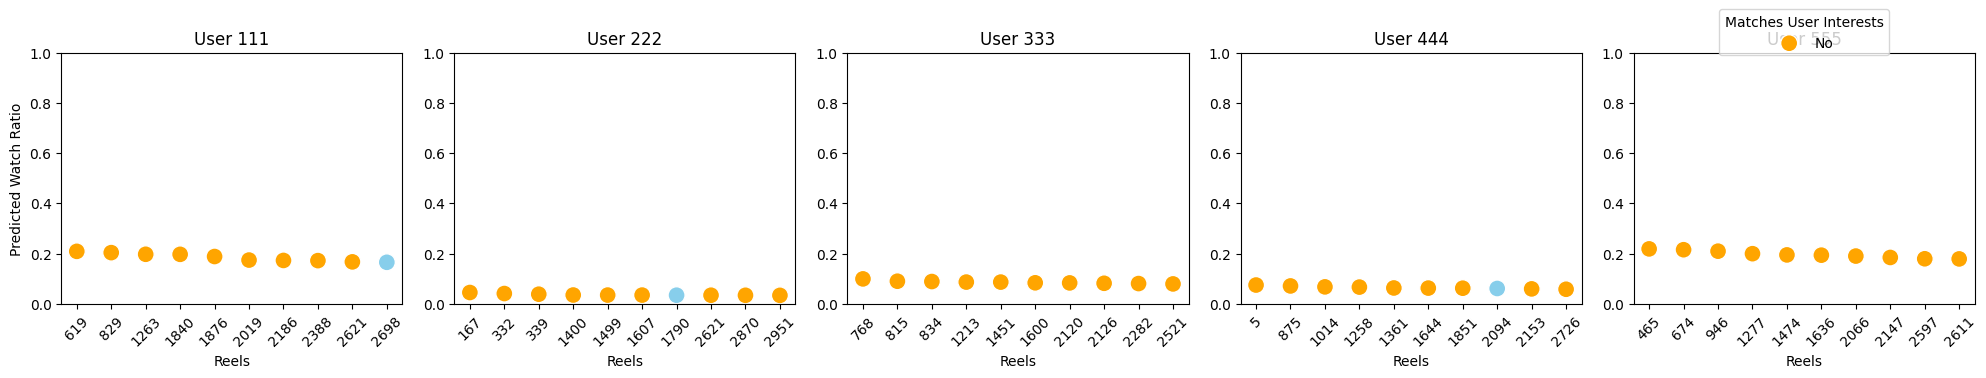

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# select 5 users
user_ids = [111, 222, 333, 444, 555]

plt.figure(figsize=(20, 4))  # 5 plots side by side

for i, user_id in enumerate(user_ids):
    user_interests = users_df[users_df['user_id'] == user_id]['interests'].values[0]
    
    # Top 10 CF recommendations
    top_reels = recommend_cf(user_id, top_k=10)
    top_reels_df = reels_df[reels_df['reel_id'].isin(top_reels.index)].copy()
    top_reels_df['score'] = top_reels.values
    
    # matches with user interests
    top_reels_df['matches_interest'] = top_reels_df['category'].apply(lambda x: x in user_interests)
    
    # sort by score
    top_reels_df.sort_values('score', ascending=False, inplace=True)
    
    # subplot for each user
    plt.subplot(1, 5, i+1)
    sns.scatterplot(
        x=range(len(top_reels_df)),
        y='score',
        hue='matches_interest',
        palette={True: 'orange', False: 'skyblue'},
        s=150,
        data=top_reels_df,
        legend=False  # remove legend for each subplot
    )
    plt.title(f"User {user_id}")
    plt.xticks(range(len(top_reels_df)), top_reels_df['reel_id'], rotation=45)
    plt.ylim(0,1)  # watch_ratio is always between 0 and 1
    plt.xlabel("Reels")
    plt.ylabel("Predicted Watch Ratio" if i==0 else "")
    
# single legend above all plots
plt.legend(title="Matches User Interests", loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2, labels=["No","Yes"])
plt.tight_layout()
plt.show()

Popularity Model

In [20]:
popularity_score = reels_df.set_index('reel_id')['total_views']
popularity_score = popularity_score / popularity_score.max()

In [21]:
top_popular = popularity_score.sort_values(ascending=False).head(10)
print(top_popular)

reel_id
280     1.000
1769    0.975
1060    0.975
465     0.925
1759    0.925
2278    0.925
2726    0.925
766     0.925
674     0.925
125     0.925
Name: total_views, dtype: float64


In [22]:
real_views = interactions_df.groupby('reel_id')['view'].sum()

# أعلى 10 من الحقيقة
top_real = real_views.sort_values(ascending=False).head(10)

print("Real Top Reels:")
print(top_real)

print("\nModel Top Reels:")
print(top_popular)

Real Top Reels:
reel_id
280     40
1769    39
1060    39
465     37
1759    37
2278    37
2726    37
766     37
674     37
125     37
Name: view, dtype: int64

Model Top Reels:
reel_id
280     1.000
1769    0.975
1060    0.975
465     0.925
1759    0.925
2278    0.925
2726    0.925
766     0.925
674     0.925
125     0.925
Name: total_views, dtype: float64


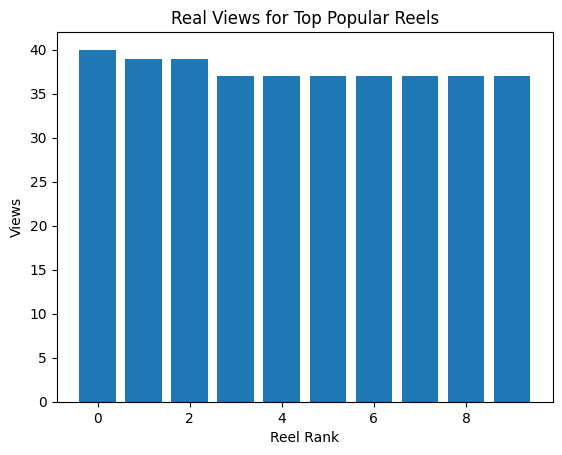

In [23]:
import matplotlib.pyplot as plt

top_ids = top_popular.index

plt.bar(range(len(top_ids)), real_views.loc[top_ids])
plt.title("Real Views for Top Popular Reels")
plt.xlabel("Reel Rank")
plt.ylabel("Views")
plt.show()

Time Decay

In [24]:
import numpy as np

current_time = interactions_df['timestamp'].max()

interactions_df['days_since'] = (current_time - interactions_df['timestamp']).dt.days

lambda_ = 0.05
interactions_df['time_weight'] = np.exp(-lambda_ * interactions_df['days_since'])

In [25]:
interactions_df[['days_since', 'time_weight']].head()

,days_since,time_weight
0,89,0.011679
1,73,0.025991
2,21,0.349938
3,22,0.332871
4,30,0.223130


In [26]:
time_decay_score = interactions_df.groupby('reel_id')['time_weight'].sum()

# normalize
time_decay_score = time_decay_score / time_decay_score.max()

print(time_decay_score.head())

reel_id
1    0.011475
2    0.306848
3    0.033053
4    0.034546
5    0.142712
Name: time_weight, dtype: float64


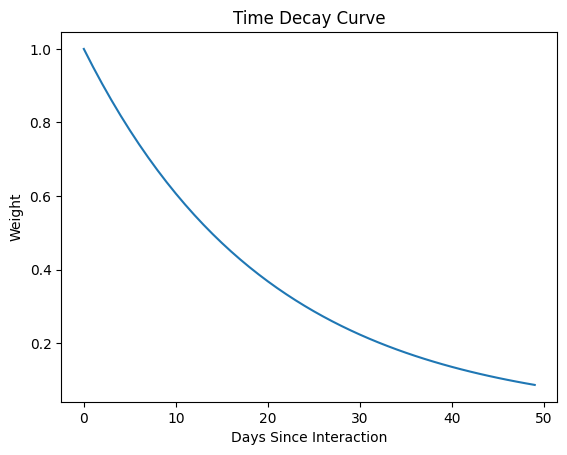

In [27]:
import matplotlib.pyplot as plt

days = np.arange(0, 50)
weights = np.exp(-0.05 * days)

plt.plot(days, weights)
plt.title("Time Decay Curve")
plt.xlabel("Days Since Interaction")
plt.ylabel("Weight")
plt.show()

Content-Based Model

Reel Features

In [28]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
reel_category_encoded = encoder.fit_transform(reels_df[['category']]).toarray()

reel_features = pd.DataFrame(
    reel_category_encoded,
    columns=encoder.get_feature_names_out(['category']),
    index=reels_df['reel_id']
)

print(reel_features.head())

         category_Beauty  category_Fashion  category_Fitness  category_Gaming  \
reel_id                                                                         
1                    0.0               0.0               0.0              1.0   
2                    0.0               0.0               0.0              1.0   
3                    0.0               0.0               0.0              0.0   
4                    1.0               0.0               0.0              0.0   
5                    0.0               0.0               0.0              1.0   

         category_Home  category_Sports  category_Technology  
reel_id                                                       
1                  0.0              0.0                  0.0  
2                  0.0              0.0                  0.0  
3                  0.0              1.0                  0.0  
4                  0.0              0.0                  0.0  
5                  0.0              0.0               

User Vector

In [29]:
interest_cols = [col for col in users_df.columns if col.startswith("interest_")]

user_vectors = users_df.set_index("user_id")[interest_cols]

Cosine Similarity

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(user_vectors, reel_features)

content_scores = pd.DataFrame(
    similarity_matrix,
    index=user_vectors.index,
    columns=reel_features.index
)

print(content_scores.head())

reel_id  1     2         3         4     5         6         7         8     \
user_id                                                                       
1         0.5   0.5  0.000000  0.000000   0.5  0.000000  0.500000  0.000000   
2         0.0   0.0  0.707107  0.707107   0.0  0.707107  0.000000  0.707107   
3         0.0   0.0  0.707107  0.000000   0.0  0.707107  0.000000  0.000000   
4         0.0   0.0  0.000000  0.707107   0.0  0.000000  0.707107  0.707107   
5         0.0   0.0  0.500000  0.000000   0.0  0.500000  0.500000  0.000000   

reel_id  9     10    ...  2991  2992      2993      2994  2995  2996  \
user_id              ...                                               
1         0.5   0.0  ...   0.5   0.0  0.000000  0.500000   0.5   0.5   
2         0.0   0.0  ...   0.0   0.0  0.707107  0.000000   0.0   0.0   
3         0.0   0.0  ...   0.0   0.0  0.707107  0.707107   0.0   0.0   
4         0.0   0.0  ...   0.0   0.0  0.000000  0.000000   0.0   0.0   
5         0.0 

In [31]:
user = users_df[users_df['user_id'] == 111]
print("User interests:", user['interests'].values)

User interests: [list(['Sports', 'Beauty', 'Home', 'Gaming'])]


In [32]:
top_reels = content_scores.loc[111].sort_values(ascending=False).head(15)

top_categories = reels_df[
    reels_df['reel_id'].isin(top_reels.index)
]['category']

print(top_categories)

0       Gaming
1       Gaming
2       Sports
3       Beauty
4       Gaming
5       Sports
2970    Gaming
2971    Beauty
2972    Gaming
2973    Gaming
2975    Beauty
2979    Sports
2980    Sports
2981      Home
2999    Beauty
Name: category, dtype: str


In [33]:
user = users_df[users_df['user_id'] == 111].iloc[0]
interests = set(user['interests'])

matches = sum([1 for c in top_categories if c in interests])

print("Match % =", matches / len(top_categories))

Match % = 1.0


Hybrid Model

In [34]:
def normalize(df):
    return (df - df.min()) / (df.max() - df.min())

In [35]:
content_norm = normalize(content_scores)
cf_norm = normalize(predicted_df)

popularity_norm = popularity_score / popularity_score.max()

In [36]:
time_decay_score = interactions_df.groupby('reel_id')['time_weight'].mean()
time_decay_score = time_decay_score / time_decay_score.max()

In [37]:
popularity_matrix = pd.DataFrame(
    np.tile(popularity_norm.values, (content_norm.shape[0], 1)),
    index=content_norm.index,
    columns=content_norm.columns
)

time_matrix = pd.DataFrame(
    np.tile(time_decay_score.values, (content_norm.shape[0], 1)),
    index=content_norm.index,
    columns=content_norm.columns
)

In [38]:
final_scores = (
    0.35 * content_norm +
    0.45 * cf_norm +
    0.1 * popularity_matrix +
    0.1 * time_matrix
)

In [39]:
def recommend_hybrid(user_id, top_k=10):
    user_scores = final_scores.loc[user_id]
    
    # إزالة الحاجات اللي شافها قبل كده
    seen_reels = interactions_df[
        interactions_df['user_id'] == user_id
    ]['reel_id']
    
    user_scores = user_scores.drop(seen_reels, errors='ignore')
    
    return user_scores.sort_values(ascending=False).head(top_k)

In [40]:
recommendations = recommend_hybrid(111)

top_reels = reels_df[
    reels_df['reel_id'].isin(recommendations.index)
][['reel_id', 'category']]

print(top_reels)

      reel_id category
331       332     Home
804       805   Beauty
1092     1093   Gaming
1262     1263   Beauty
2009     2010   Gaming
2291     2292   Gaming
2764     2765   Sports
2799     2800     Home
2817     2818   Beauty
2906     2907   Gaming


In [41]:
print(top_reels['category'].value_counts())

category
Gaming    4
Beauty    3
Home      2
Sports    1
Name: count, dtype: int64


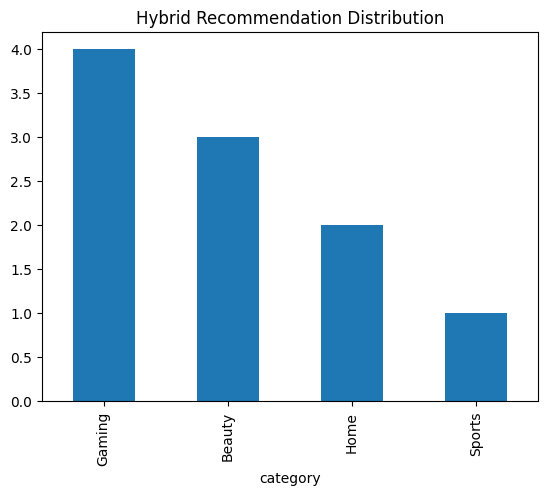

In [42]:
import matplotlib.pyplot as plt

top_reels['category'].value_counts().plot(kind='bar')
plt.title("Hybrid Recommendation Distribution")
plt.show()

In [43]:
print("Content:")
print(content_scores.loc[111].sort_values(ascending=False).head(5))

print("\nCF:")
print(predicted_df.loc[111].sort_values(ascending=False).head(5))

print("\nHybrid:")
print(recommend_hybrid(111))

Content:
reel_id
3000    0.5
1       0.5
2       0.5
3       0.5
4       0.5
Name: 111, dtype: float64

CF:
reel_id
829     0.208848
2186    0.203804
1876    0.197189
2621    0.196950
2388    0.188297
Name: 111, dtype: float64

Hybrid:
reel_id
805     0.846173
2800    0.838229
2010    0.830941
332     0.822409
2292    0.818700
2818    0.814326
2765    0.812785
1263    0.806984
1093    0.804902
2907    0.804163
Name: 111, dtype: float64


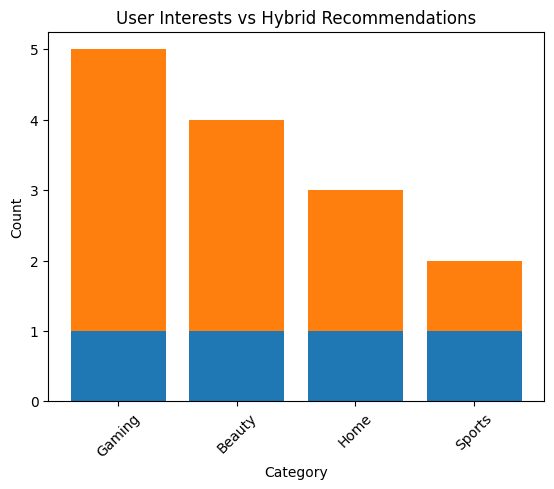

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

user_id = 111

# 🎯 1. اهتمامات اليوزر
user = users_df[users_df['user_id'] == user_id]
user_interests = user['interests'].values[0]

# نحولها لـ DataFrame
user_interest_counts = pd.Series(user_interests).value_counts()

# 🤖 2. توصيات الـ Hybrid
recommended = recommend_hybrid(user_id)

recommended_categories = reels_df[
    reels_df['reel_id'].isin(recommended.index)
]['category']

recommended_counts = recommended_categories.value_counts()

# 🧠 3. توحيد الـ categories
all_categories = list(set(user_interest_counts.index).union(set(recommended_counts.index)))

user_counts = [user_interest_counts.get(cat, 0) for cat in all_categories]
rec_counts = [recommended_counts.get(cat, 0) for cat in all_categories]

# 📊 4. الرسم
x = range(len(all_categories))

plt.figure()

plt.bar(x, user_counts)
plt.bar(x, rec_counts, bottom=user_counts)

plt.xticks(x, all_categories, rotation=45)

plt.title("User Interests vs Hybrid Recommendations")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

Evaluation

Train / Test Split

In [45]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    interactions_df,
    test_size=0.2,
    random_state=42
)

Actual Categories

In [46]:
def get_actual_categories(user_id):
    reels = test_df[test_df['user_id'] == user_id]['reel_id']
    return reels_df[reels_df['reel_id'].isin(reels)]['category'].tolist()

In [47]:
def recommend_reels(user_id, k=10):
    return (
        final_scores.loc[user_id]
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

unique category

In [48]:
def unique_category_recommendations(user_id, k=10):

    user_scores = final_scores.loc[user_id].sort_values(ascending=False)

    selected_reels = []
    seen_categories = set()

    for reel_id in user_scores.index:

        cat = reels_df.loc[reels_df['reel_id'] == reel_id, 'category'].values[0]

        if cat not in seen_categories:
            selected_reels.append(reel_id)
            seen_categories.add(cat)

        if len(selected_reels) == k:
            break

    return selected_reels

Predicted Categories

In [49]:
def get_predicted_categories(user_id, k=10):
    reels = unique_category_recommendations(user_id, k)
    return reels_df[reels_df['reel_id'].isin(reels)]['category'].tolist()

Metrics

Precision

In [50]:
def precision_at_k(actual, pred):
    actual = set(actual)
    return len(set(pred) & actual) / len(pred)

Recall

In [51]:
def recall_at_k(actual, pred):
    actual = set(actual)
    return len(set(pred) & actual) / len(actual)

NDCG

In [52]:
import numpy as np

def ndcg_at_k(actual, pred, k=10):

    actual = set(actual)

    dcg = 0
    for i, item in enumerate(pred[:k]):
        if item in actual:
            dcg += 1 / np.log2(i + 2)

    ideal = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))

    return dcg / ideal if ideal > 0 else 0

In [53]:
user_id = 111

actual = get_actual_categories(user_id)
pred = get_predicted_categories(user_id)

print("Actual:", actual)
print("Predicted:", pred)

print("Precision:", precision_at_k(actual, pred))
print("Recall:", recall_at_k(actual, pred))
print("NDCG:", ndcg_at_k(actual, pred))

Actual: ['Gaming', 'Beauty', 'Technology', 'Beauty', 'Beauty', 'Beauty', 'Gaming', 'Gaming', 'Sports', 'Beauty', 'Sports', 'Beauty', 'Gaming', 'Sports']
Predicted: ['Fashion', 'Technology', 'Beauty', 'Gaming', 'Fitness', 'Sports', 'Home']
Precision: 0.5714285714285714
Recall: 1.0
NDCG: 0.7486761295186739


In [54]:
users = test_df['user_id'].unique()

p_list, r_list, n_list = [], [], []

for u in users[:200]:

    actual = get_actual_categories(u)
    pred = get_predicted_categories(u)

    p_list.append(precision_at_k(actual, pred))
    r_list.append(recall_at_k(actual, pred))
    n_list.append(ndcg_at_k(actual, pred))

print("Precision:", np.mean(p_list))
print("Recall:", np.mean(r_list))
print("NDCG:", np.mean(n_list))

Precision: 0.5657142857142857
Recall: 1.0
NDCG: 0.8065350933698144


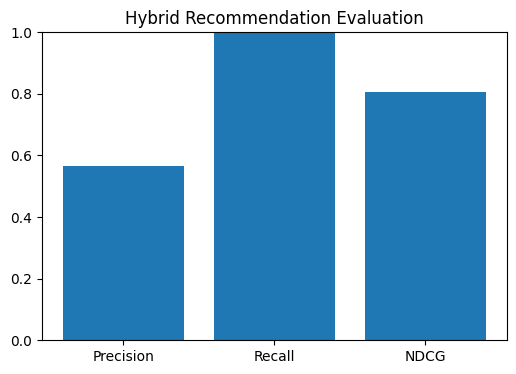

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    ["Precision", "Recall", "NDCG"],
    [np.mean(p_list), np.mean(r_list), np.mean(n_list)]
)

plt.title("Hybrid Recommendation Evaluation")
plt.ylim(0, 1)
plt.show()

Backend Output

In [56]:
unique_category_recommendations(111)

[805, 2800, 2010, 2765, 2698, 556, 670]

Cold Start Handling

Level 1: Normal Hybrid

Level 2: Content-Based

In [57]:
def cold_start_content(user_id, k=10):

    user = users_df[users_df['user_id'] == user_id]

    if len(user) == 0:
        return popularity_score(k)

    interests = user['interests'].values[0]

    scores = reels_df.copy()
    scores['match'] = scores['category'].apply(
        lambda x: 1 if x in interests else 0
    )

    return scores.sort_values('match', ascending=False)['reel_id'].head(k).tolist()

Level 3: Popularity (Worst case fallback)

In [58]:
def popularity_recommendation(k=10):
    return (
        interactions_df.groupby('reel_id')['view']
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

In [59]:
def recommend(user_id, k=10):

    if user_id in final_scores.index:
        return unique_category_recommendations(user_id, k)

    elif user_id in users_df['user_id'].values:
        return cold_start_content(user_id, k)

    else:
        return popularity_recommendation(k)

In [60]:
recommend(111)

[805, 2800, 2010, 2765, 2698, 556, 670]

In [61]:
recommend(111000)

[280, 1769, 1060, 465, 1759, 2278, 2726, 766, 674, 125]

In [62]:
from models.save_models import save_all

save_all(final_scores, reels_df, popularity_score)